# Causal analysis of the Adaptive-NOP toy model

This notebook tests whether token 0 functions as a near-null attention destination in the trained no-op toy model. We keep the learned attention matrix fixed and intervene on the sink value by (i) setting it to zero, (ii) replacing it with the sink value from another example, and (iii) replacing it with a norm-matched non-sink value as a positive control. We additionally redirect attention away from the sink. The Adaptive-NOP interpretation predicts little change under the first two interventions, but a selective change for no-op-target queries when a non-null payload is injected or their attention is redirected.

In [ ]:
from pathlib import Path
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

DMODEL = 64
HEAD_DIM = 64
SEQ_LEN = 32
SINK_INDEX = 0

CHECKPOINT_PATH = Path("toy_noop_dedicated_sink_checkpoint.pt")

TRAIN_IF_MISSING = True
TRAIN_BATCH_SIZE = 1024
TRAIN_STEPS = 30_000

device: cuda


## Model and task

The returned normalized residual stream, attention matrix, and value vectors allow us to recompute the output after an intervention without changing the queries or keys.

In [ ]:
class OneHead(nn.Module):
    def __init__(self, d=DMODEL, h=HEAD_DIM, l=SEQ_LEN):
        super().__init__()

        self.norm = nn.LayerNorm(d)

        self.Wq = nn.Linear(d, h, bias=False)
        self.Wk = nn.Linear(d, h, bias=False)
        self.Wv = nn.Linear(d, h, bias=False)
        self.Wo = nn.Linear(h, d, bias=False)

        self.pos = nn.Parameter(torch.randn(l, d) * 0.02)
        self.bos = nn.Parameter(torch.randn(d) * 0.02)

    def forward(self, x, ret=False):
        x_in = x

        # Pre-norm attention input.
        z = x.clone()
        z[:, 0, :] = z[:, 0, :] + self.bos
        z = self.norm(z + self.pos.unsqueeze(0))

        Q = self.Wq(z)
        K = self.Wk(z)
        V = self.Wv(z)

        scores = Q @ K.transpose(1, 2) / math.sqrt(Q.shape[-1])
        A = torch.softmax(scores, dim=-1)

        # Standard pre-norm residual: the residual stream is x_in, not z.
        O = x_in + self.Wo(A @ V)

        cache = {
            "Q": Q,
            "K": K,
            "V": V,
            "scores": scores,
            "x_in": x_in,
            "residual": x_in,
        }

        return (O, A, cache) if ret else O


def make_target(x, v_gate):
    """
    Positive gate:
        the desired output is zero, requiring an active attention update.

    Negative gate:
        the desired output is x, so the attention head should perform a NOP.
    """
    zero_target_mask = x @ v_gate > 0
    target = (~zero_target_mask).unsqueeze(-1) * x

    return target, zero_target_mask

In [ ]:
def train_noop_model(
    steps=TRAIN_STEPS,
    batch_size=TRAIN_BATCH_SIZE,
):
    model = OneHead().to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-3,
        weight_decay=1e-4,
    )

    v_gate = torch.randn(DMODEL, device=device)
    v_gate = v_gate / v_gate.norm()

    # Token positions included in the task loss.
    data_positions = (
        torch.arange(SEQ_LEN, device=device)
        != SINK_INDEX
    )

    model.train()

    for step in range(1, steps + 1):
        x = torch.randn(
            batch_size,
            SEQ_LEN,
            DMODEL,
            device=device,
        )

        # Token 0 is a dedicated learned sink token rather than a
        # randomly sampled data token. Its representation inside the
        # attention block is provided by BOS and positional embeddings.
        x[:, SINK_INDEX, :] = 0.0

        target, _ = make_target(x, v_gate)
        output = model(x)

        # The dedicated sink token is not part of the task.
        loss = F.mse_loss(
            output[:, data_positions, :],
            target[:, data_positions, :],
        )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if step == 1 or step % 5_000 == 0:
            print(
                f"step {step:5d} | "
                f"loss {loss.item():.4e}"
            )

    return model.eval(), v_gate


if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location=device,
    )

    required_keys = {
        "model_state_dict",
        "v_gate",
    }

    missing_keys = required_keys - set(checkpoint)

    if missing_keys:
        raise KeyError(
            f"Checkpoint is missing: {sorted(missing_keys)}"
        )

    model = OneHead().to(device)
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )
    model.eval()

    v_gate = checkpoint["v_gate"].to(device)

    print(f"Loaded {CHECKPOINT_PATH}")

elif TRAIN_IF_MISSING:
    model, v_gate = train_noop_model()

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "v_gate": v_gate.detach().cpu(),
            "seed": SEED,
            "train_steps": TRAIN_STEPS,
            "residual_type": "pre_norm",
            "dedicated_sink_token": True,
            "sink_index": SINK_INDEX,
        },
        CHECKPOINT_PATH,
    )

    print(f"Saved {CHECKPOINT_PATH}")

else:
    raise FileNotFoundError(
        f"Place a checkpoint at {CHECKPOINT_PATH} "
        "or set TRAIN_IF_MISSING=True."
    )

step     1 | loss 5.0232e-01
step  5000 | loss 1.8505e-02
step 10000 | loss 1.8594e-02
step 15000 | loss 1.8371e-02
step 20000 | loss 1.8825e-02
step 25000 | loss 1.8472e-02
step 30000 | loss 1.9255e-02
Saved toy_noop_dedicated_sink_checkpoint.pt


## Intervention definitions

For value interventions, only the value at token 0 is changed; the baseline attention matrix is reused exactly. The donor-sink intervention permutes sink values across examples within a batch. The matched non-null intervention instead inserts the value of token 1 from a different example, providing a positive control with an in-distribution payload. The final intervention removes token 0 as a destination and renormalizes the remaining attention weights.

In [ ]:
def output_from_cache(model, cache, A=None, V=None):
    if A is None:
        A = cache["A"]

    if V is None:
        V = cache["V"]

    return cache["residual"] + model.Wo(A @ V)


@torch.no_grad()
def intervene(model, x):
    baseline, A, raw_cache = model(x, ret=True)
    cache = dict(raw_cache, A=A)

    V = cache["V"]

    # Verify that recomputing the unmodified output is exact.
    torch.testing.assert_close(
        output_from_cache(model, cache),
        baseline,
    )

    # 1. Remove the sink payload.
    V_zero = V.clone()
    V_zero[:, SINK_INDEX, :] = 0.0

    # 2. Replace each sink value with the sink value from another example.
    V_donor_sink = V.clone()
    V_donor_sink[:, SINK_INDEX, :] = (
        V.roll(1, dims=0)[:, SINK_INDEX, :]
    )

    # 3. Positive control: insert an ordinary non-sink value from
    #    another example at the sink destination.
    V_donor_non_sink = V.clone()
    V_donor_non_sink[:, SINK_INDEX, :] = (
        V.roll(1, dims=0)[:, 1, :]
    )

    # 4. Remove the sink as an attention destination and renormalize.
    A_redirect = A.clone()
    A_redirect[:, :, SINK_INDEX] = 0.0

    remaining_mass = A_redirect.sum(
        dim=-1,
        keepdim=True,
    )

    A_redirect = (
        A_redirect
        / remaining_mass.clamp_min(1e-12)
    )

    outputs = {
        "Baseline": baseline,
        "Zero sink value": output_from_cache(
            model,
            cache,
            V=V_zero,
        ),
        "Donor sink value": output_from_cache(
            model,
            cache,
            V=V_donor_sink,
        ),
        "Donor non-sink value": output_from_cache(
            model,
            cache,
            V=V_donor_non_sink,
        ),
        "Redirect sink attention": output_from_cache(
            model,
            cache,
            A=A_redirect,
        ),
    }

    return outputs, A, V

## Evaluation

We report task MSE and the RMS change from the baseline output separately for no-op-target and identity-target queries. Query 0 is excluded from the groupwise analysis because attention from token 0 to itself is ordinary diagonal self-attention and should not be interpreted as routing another token to the sink.

In [ ]:
def masked_rms(delta, mask):
    selected = delta[mask]

    if selected.numel() == 0:
        return float("nan")

    return selected.square().mean().sqrt().item()


@torch.no_grad()
def evaluate_causal_interventions(
    model,
    v_gate,
    n_batches=64,
    batch_size=256,
):
    result_rows = []
    routing_rows = []

    model.eval()

    data_positions = (
        torch.arange(SEQ_LEN, device=device)
        != SINK_INDEX
    )

    for batch_id in range(n_batches):
        x = torch.randn(
            batch_size,
            SEQ_LEN,
            DMODEL,
            device=device,
        )

        # Match the training distribution: token 0 is a dedicated
        # learned sink token and contains no input-dependent data.
        x[:, SINK_INDEX, :] = 0.0

        target, zero_target_mask = make_target(
            x,
            v_gate,
        )

        outputs, A, V = intervene(model, x)
        baseline = outputs["Baseline"]

        valid_queries = torch.ones_like(
            zero_target_mask,
            dtype=torch.bool,
        )
        valid_queries[:, SINK_INDEX] = False

        # These queries should preserve the residual input and therefore
        # require the attention head to perform a NOP.
        adaptive_nop_queries = (
            (~zero_target_mask) & valid_queries
        )

        # These queries require an active attention update that cancels
        # the residual input.
        zero_output_queries = (
            zero_target_mask & valid_queries
        )

        attention_to_sink = A[:, :, SINK_INDEX]

        # The relevant payload is the value after the output projection.
        projected_values = model.Wo(V)

        common_routing_values = {
            "batch": batch_id,
            "sink_value_norm": (
                projected_values[:, SINK_INDEX, :]
                .norm(dim=-1)
                .mean()
                .item()
            ),
            "non_sink_value_norm": (
                projected_values[:, data_positions, :]
                .norm(dim=-1)
                .mean()
                .item()
            ),
        }

        routing_rows.append(
            {
                **common_routing_values,
                "group": "Adaptive NOP (identity target)",
                "attention_to_sink": (
                    attention_to_sink[adaptive_nop_queries]
                    .mean()
                    .item()
                ),
            }
        )

        routing_rows.append(
            {
                **common_routing_values,
                "group": "Zero-output target",
                "attention_to_sink": (
                    attention_to_sink[zero_output_queries]
                    .mean()
                    .item()
                ),
            }
        )

        for intervention_name, output in outputs.items():
            delta = output - baseline

            # Task error is evaluated only over data tokens because the
            # dedicated sink token has no task target.
            task_mse = F.mse_loss(
                output[:, data_positions, :],
                target[:, data_positions, :],
            ).item()

            result_rows.append(
                {
                    "batch": batch_id,
                    "intervention": intervention_name,
                    "task_mse": task_mse,
                    "delta_rms_adaptive_nop": masked_rms(
                        delta,
                        adaptive_nop_queries,
                    ),
                    "delta_rms_zero_output": masked_rms(
                        delta,
                        zero_output_queries,
                    ),
                }
            )

    results = pd.DataFrame(result_rows)
    routing = pd.DataFrame(routing_rows)

    return results, routing


results, routing = evaluate_causal_interventions(
    model,
    v_gate,
)

summary = (
    results
    .groupby("intervention", sort=False)
    .agg(
        task_mse_mean=(
            "task_mse",
            "mean",
        ),
        task_mse_sem=(
            "task_mse",
            "sem",
        ),
        delta_adaptive_nop_mean=(
            "delta_rms_adaptive_nop",
            "mean",
        ),
        delta_adaptive_nop_sem=(
            "delta_rms_adaptive_nop",
            "sem",
        ),
        delta_zero_output_mean=(
            "delta_rms_zero_output",
            "mean",
        ),
        delta_zero_output_sem=(
            "delta_rms_zero_output",
            "sem",
        ),
    )
    .reset_index()
)

routing_summary = (
    routing
    .groupby("group")
    .agg(
        attention_to_sink_mean=(
            "attention_to_sink",
            "mean",
        ),
        attention_to_sink_sem=(
            "attention_to_sink",
            "sem",
        ),
        sink_value_norm_mean=(
            "sink_value_norm",
            "mean",
        ),
        sink_value_norm_sem=(
            "sink_value_norm",
            "sem",
        ),
        non_sink_value_norm_mean=(
            "non_sink_value_norm",
            "mean",
        ),
        non_sink_value_norm_sem=(
            "non_sink_value_norm",
            "sem",
        ),
    )
    .reset_index()
)

display(summary)
display(routing_summary)

,intervention,task_mse_mean,task_mse_sem,delta_adaptive_nop_mean,delta_adaptive_nop_sem,delta_zero_output_mean,delta_zero_output_sem
0,Baseline,0.018694,0.000084,0.000000,0.000000e+00,0.000000,0.000000
1,Zero sink value,0.018669,0.000084,0.007849,5.864516e-07,0.000645,0.000006
2,Donor sink value,0.018694,0.000084,0.000000,0.000000e+00,0.000000,0.000000
3,Donor non-sink value,0.500093,0.000633,0.979167,1.127659e-04,0.080533,0.000809
4,Redirect sink attention,0.143905,0.000408,0.499524,7.821222e-04,0.081149,0.000818


,group,attention_to_sink_mean,attention_to_sink_sem,sink_value_norm_mean,sink_value_norm_sem,non_sink_value_norm_mean,non_sink_value_norm_sem
0,Adaptive NOP (identity target),0.992918,0.000106,0.063138,0.0,7.872467,0.000148
1,Zero-output target,0.012159,0.000193,0.063138,0.0,7.872467,0.000148


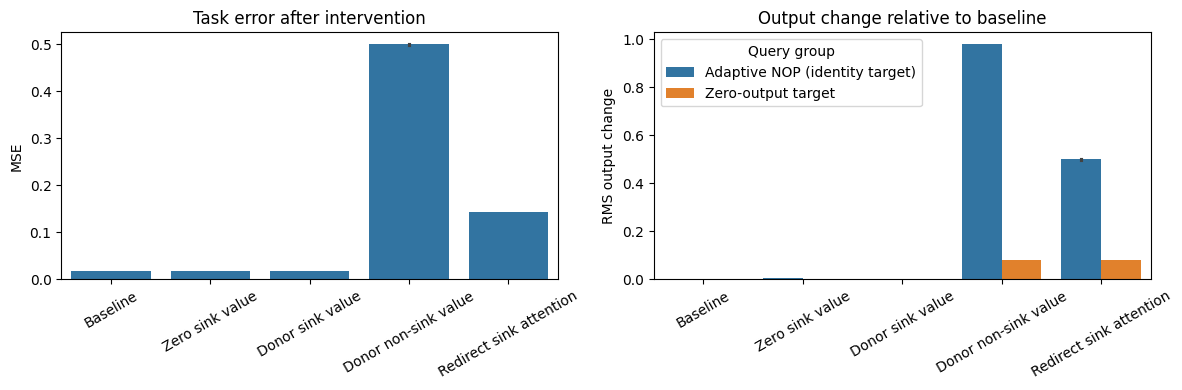

In [ ]:
plot_df = results.melt(
    id_vars=[
        "batch",
        "intervention",
        "task_mse",
    ],
    value_vars=[
        "delta_rms_adaptive_nop",
        "delta_rms_zero_output",
    ],
    var_name="query_group",
    value_name="rms_change",
)

plot_df["query_group"] = plot_df["query_group"].map(
    {
        "delta_rms_adaptive_nop": (
            "Adaptive NOP (identity target)"
        ),
        "delta_rms_zero_output": (
            "Zero-output target"
        ),
    }
)

intervention_order = [
    "Baseline",
    "Zero sink value",
    "Donor sink value",
    "Donor non-sink value",
    "Redirect sink attention",
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4),
)

sns.barplot(
    data=results,
    x="intervention",
    y="task_mse",
    order=intervention_order,
    errorbar="se",
    ax=axes[0],
)

axes[0].set_title("Task error after intervention")
axes[0].set_xlabel("")
axes[0].set_ylabel("MSE")

sns.barplot(
    data=plot_df,
    x="intervention",
    y="rms_change",
    hue="query_group",
    order=intervention_order,
    errorbar="se",
    ax=axes[1],
)

axes[1].set_title("Output change relative to baseline")
axes[1].set_xlabel("")
axes[1].set_ylabel("RMS output change")
axes[1].legend(title="Query group")

for ax in axes:
    ax.tick_params(
        axis="x",
        rotation=30,
    )

plt.tight_layout()

plt.savefig(
    "noop_causal_intervention_prenorm.pdf",
    bbox_inches="tight",
)

plt.show()